In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA
from scipy.stats import zscore

## 1. Use a new Python notebook and read the data set. Data pre-processing - Understand the data and treat missing values (Use box plot), outliers (5 points)

In [2]:
vehicle_df=pd.read_csv('vehicle.csv')
vehicle_df.head(10)

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus
5,107,NaN,106.0,172.0,50.0,6,255.0,26.0,28.0,169,280.0,957.0,264.0,85.0,5.0,9.0,181.0,183,bus
6,97,43.0,73.0,173.0,65.0,6,153.0,42.0,19.0,143,176.0,361.0,172.0,66.0,13.0,1.0,200.0,204,bus
7,90,43.0,66.0,157.0,65.0,9,137.0,48.0,18.0,146,162.0,281.0,164.0,67.0,3.0,3.0,193.0,202,van
8,86,34.0,62.0,140.0,61.0,7,122.0,54.0,17.0,127,141.0,223.0,112.0,64.0,2.0,14.0,200.0,208,van
9,93,44.0,98.0,NaN,62.0,11,183.0,36.0,22.0,146,202.0,505.0,152.0,64.0,4.0,14.0,195.0,204,car


In [3]:
print(vehicle_df.shape)
print(vehicle_df.info())
print(vehicle_df.describe())

(846, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
compactness                    846 non-null int64
circularity                    841 non-null float64
distance_circularity           842 non-null float64
radius_ratio                   840 non-null float64
pr.axis_aspect_ratio           844 non-null float64
max.length_aspect_ratio        846 non-null int64
scatter_ratio                  845 non-null float64
elongatedness                  845 non-null float64
pr.axis_rectangularity         843 non-null float64
max.length_rectangularity      846 non-null int64
scaled_variance                843 non-null float64
scaled_variance.1              844 non-null float64
scaled_radius_of_gyration      844 non-null float64
scaled_radius_of_gyration.1    842 non-null float64
skewness_about                 840 non-null float64
skewness_about.1               845 non-null float64
skewness_about.2               845 non-null float64
hollows

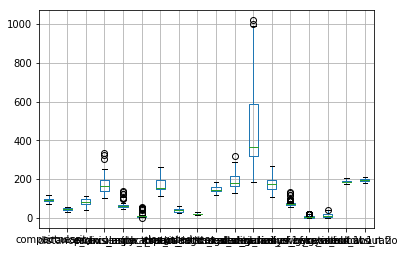

In [4]:
vehicle_df.boxplot()

In [5]:
# Treat Missing Values

# vehicle_df = vehicle_df.applymap(lambda x: np.nan if isinstance(x, basestring) and x.isspace() else x)

vehicle_df=vehicle_df.fillna(vehicle_df.median())


# changing class values for van=1, car=2 and bus=3
#vehicle_df.class.loc[(df['class'] > "van")] = 1
vehicle_df['class'] = np.where(vehicle_df['class'] == "van", 1, vehicle_df['class'])
vehicle_df['class'] = np.where(vehicle_df['class'] == "car", 2, vehicle_df['class'])
vehicle_df['class'] = np.where(vehicle_df['class'] == "bus", 3, vehicle_df['class'])

vehicle_df.head(10)


,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,1
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,1
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,2
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,1
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,3
5,107,44.0,106.0,172.0,50.0,6,255.0,26.0,28.0,169,280.0,957.0,264.0,85.0,5.0,9.0,181.0,183,3
6,97,43.0,73.0,173.0,65.0,6,153.0,42.0,19.0,143,176.0,361.0,172.0,66.0,13.0,1.0,200.0,204,3
7,90,43.0,66.0,157.0,65.0,9,137.0,48.0,18.0,146,162.0,281.0,164.0,67.0,3.0,3.0,193.0,202,1
8,86,34.0,62.0,140.0,61.0,7,122.0,54.0,17.0,127,141.0,223.0,112.0,64.0,2.0,14.0,200.0,208,1
9,93,44.0,98.0,167.0,62.0,11,183.0,36.0,22.0,146,202.0,505.0,152.0,64.0,4.0,14.0,195.0,204,2


In [6]:
# Removal of Outliers using IQR

# a number "a" from the vector "x" is an outlier if 
# a > median(x)+1.5*iqr(x) or a < median-1.5*iqr(x)
# iqr: interquantile range = third interquantile - first interquantile
def outliers(x): 
       return np.abs(x- x.median()) > 1.5*(x.quantile(.75)-x.quantile(0.25))

# Give the outliers for the first column for example
        #vehicle_df.data1[outliers(vehicle_df.data1)]

#The function above return a boolean vector: True if the element is an outlier. False, otherwise.

#Now, to replace the upper and lower outliers, let's write another small function and apply it on all the dataframe:    
# Replace the upper outlier(s) with the 95th percentile and the lower one(s) with the 5th percentile 
#def replace(x):   # x is a vector
#       out = x[outliers(x)]
#       return x.replace(to_replace = [out.min(),out.max()], 
#                        value = [np.percentile(x,5),np.percentile(x,95)])

# Apply replace() on each column of the dataframe
#vehicle_df = vehicle_df.apply(replace,axis=1)

# Finally, remove the rows containing any outlier:
vehicle_df = vehicle_df[~vehicle_df.apply(outliers).any(axis=1)]


In [7]:
vehicle_df.shape

(664, 19)

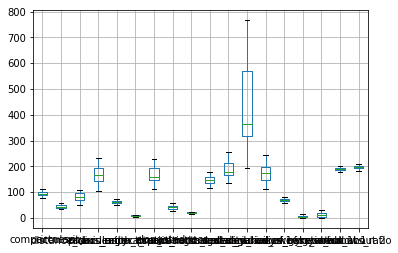

In [8]:
vehicle_df.boxplot()

## 2. Understanding the attributes - Find relationship between different attributes (Independent variables) and choose carefully which all attributes have to be a part of the analysis and why (5 points)

In [9]:
vehicle_df.corr()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
compactness,1.000000,0.651458,0.774564,0.751466,0.222187,0.550079,0.798094,-0.768836,0.804512,0.649104,0.777087,0.803683,0.528035,-0.313886,0.182461,0.144390,0.335626,0.449311
circularity,0.651458,1.000000,0.777382,0.630939,0.221024,0.609767,0.832903,-0.798400,0.831251,0.960346,0.796864,0.824646,0.935538,0.072877,0.153624,-0.013747,-0.117275,0.085625
distance_circularity,0.774564,0.777382,1.000000,0.803824,0.247656,0.714863,0.913532,-0.901965,0.906477,0.753885,0.896775,0.902467,0.690122,-0.231557,0.109652,0.238172,0.113906,0.359392
radius_ratio,0.751466,0.630939,0.803824,1.000000,0.659205,0.454294,0.824795,-0.862008,0.801754,0.557731,0.844019,0.819816,0.557832,-0.388415,0.035252,0.151983,0.411378,0.523388
pr.axis_aspect_ratio,0.222187,0.221024,0.247656,0.659205,1.000000,0.077892,0.261213,-0.342548,0.233358,0.155851,0.293021,0.256045,0.207798,-0.231611,-0.069484,-0.048992,0.366277,0.376960
max.length_aspect_ratio,0.550079,0.609767,0.714863,0.454294,0.077892,1.000000,0.593640,-0.553709,0.603203,0.694608,0.522745,0.569474,0.488803,-0.216007,0.073854,0.145753,-0.042085,0.337219
scatter_ratio,0.798094,0.832903,0.913532,0.824795,0.261213,0.593640,1.000000,-0.975543,0.986685,0.789985,0.974431,0.991993,0.759821,-0.061091,0.081737,0.212527,0.044848,0.222206
elongatedness,-0.768836,-0.798400,-0.901965,-0.862008,-0.342548,-0.553709,-0.975543,1.000000,-0.952670,-0.744806,-0.974269,-0.962864,-0.735578,0.113950,-0.061193,-0.171667,-0.134742,-0.285005
pr.axis_rectangularity,0.804512,0.831251,0.906477,0.801754,0.233358,0.603203,0.986685,-0.952670,1.000000,0.796059,0.956247,0.984162,0.755554,-0.055086,0.095162,0.217786,0.027599,0.213195
max.length_rectangularity,0.649104,0.960346,0.753885,0.557731,0.155851,0.694608,0.789985,-0.744806,0.796059,1.000000,0.733612,0.780158,0.866256,0.064147,0.141670,0.013835,-0.120489,0.114607


# Obeservation: For the target Variable "status" all the feature Variables don't have correlation in range -0.1 to 0.1,Except skewness_about, skewness_about.1 and skewness_about.2, so no either from these 3 Feature variable can be dropped to be dropped.


In [10]:
# Prepare the data for applying VIF for MULTICOLLINEARITY on Dataframe
X=vehicle_df.drop(["class"], axis=1)
y=vehicle_df['class']

X.head(10)

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207
6,97,43.0,73.0,173.0,65.0,6,153.0,42.0,19.0,143,176.0,361.0,172.0,66.0,13.0,1.0,200.0,204
7,90,43.0,66.0,157.0,65.0,9,137.0,48.0,18.0,146,162.0,281.0,164.0,67.0,3.0,3.0,193.0,202
8,86,34.0,62.0,140.0,61.0,7,122.0,54.0,17.0,127,141.0,223.0,112.0,64.0,2.0,14.0,200.0,208
9,93,44.0,98.0,167.0,62.0,11,183.0,36.0,22.0,146,202.0,505.0,152.0,64.0,4.0,14.0,195.0,204
10,86,36.0,70.0,143.0,61.0,9,133.0,50.0,18.0,130,153.0,266.0,127.0,66.0,2.0,10.0,194.0,202
11,90,34.0,66.0,136.0,55.0,6,123.0,54.0,17.0,118,148.0,224.0,118.0,65.0,5.0,26.0,196.0,202


In [11]:
vehicle_df.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,1
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,1
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,2
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,1
6,97,43.0,73.0,173.0,65.0,6,153.0,42.0,19.0,143,176.0,361.0,172.0,66.0,13.0,1.0,200.0,204,3


In [12]:
# Function for applying VIF for MULTICOLLINEARITY on Dataframe for X Freatures

from statsmodels.stats.outliers_influence import variance_inflation_factor    

def calculate_vif_(X, thresh=100):
    cols = X.columns
    variables = np.arange(X.shape[1])
    dropped=True
    while dropped:
        dropped=False
        c = X[cols[variables]].values
        vif = [variance_inflation_factor(c, ix) for ix in np.arange(c.shape[1])]
        
        maxloc = vif.index(max(vif))
        if max(vif) > thresh:
            print('dropping \'' + X[cols[variables]].columns[maxloc] + '\' at index: ' + str(maxloc))
            variables = np.delete(variables, maxloc)
            dropped=True
            
            print('Remaining variables:')
            print(X.columns[variables])
            return X[cols[variables]]

In [13]:
calculate_vif_(X, thresh=100)

dropping 'skewness_about.2' at index: 16
Remaining variables:
Index(['compactness', 'circularity', 'distance_circularity', 'radius_ratio',
       'pr.axis_aspect_ratio', 'max.length_aspect_ratio', 'scatter_ratio',
       'elongatedness', 'pr.axis_rectangularity', 'max.length_rectangularity',
       'scaled_variance', 'scaled_variance.1', 'scaled_radius_of_gyration',
       'scaled_radius_of_gyration.1', 'skewness_about', 'skewness_about.1',
       'hollows_ratio'],
      dtype='object')


,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,hollows_ratio
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,197
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,199
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,196
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,207
6,97,43.0,73.0,173.0,65.0,6,153.0,42.0,19.0,143,176.0,361.0,172.0,66.0,13.0,1.0,204
7,90,43.0,66.0,157.0,65.0,9,137.0,48.0,18.0,146,162.0,281.0,164.0,67.0,3.0,3.0,202
8,86,34.0,62.0,140.0,61.0,7,122.0,54.0,17.0,127,141.0,223.0,112.0,64.0,2.0,14.0,208
9,93,44.0,98.0,167.0,62.0,11,183.0,36.0,22.0,146,202.0,505.0,152.0,64.0,4.0,14.0,204
10,86,36.0,70.0,143.0,61.0,9,133.0,50.0,18.0,130,153.0,266.0,127.0,66.0,2.0,10.0,202
11,90,34.0,66.0,136.0,55.0,6,123.0,54.0,17.0,118,148.0,224.0,118.0,65.0,5.0,26.0,202


# Observation using VIF Feature 'skewness_about.2' required be dropped.

## 3. Use PCA from scikit learn and elbow plot to find out reduced number of dimension (which covers more than 95% of the variance) - 10 points

In [14]:
# scaling the data before PCA
data = vehicle_df.drop(["skewness_about.2","class"], axis=1) 
from sklearn.preprocessing import scale
data = pd.DataFrame(scale(data), columns=['compactness', 'circularity', 'distance_circularity', 'radius_ratio', 'pr.axis_aspect_ratio', 'max.length_aspect_ratio', 'scatter_ratio', 'elongatedness', 'pr.axis_rectangularity', 'max.length_rectangularity', 'scaled_variance', 'scaled_variance.1', 'scaled_radius_of_gyration', 'scaled_radius_of_gyration.1', 'skewness_about', 'skewness_about.1', 'hollows_ratio'])
data.head()

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:4: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by the scale function.
  after removing the cwd from sys.path.


,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,hollows_ratio
0,0.211964,0.567160,0.048053,0.323181,2.036169,0.890536,-0.176273,0.129970,-0.192468,0.807552,-0.389737,-0.320761,0.360687,-0.237840,0.028483,0.452660,0.115315
1,-0.312223,-0.626213,0.116522,-0.913565,-0.864738,0.376795,-0.608542,0.538974,-0.622766,-0.339278,-0.612444,-0.634492,-0.484441,0.158461,0.720418,0.210463,0.427205
2,1.391384,0.908124,1.622857,1.359373,0.875806,0.890536,1.320044,-1.233378,1.098427,0.735876,1.354799,1.318325,1.530865,0.356611,1.873644,-0.395029,-0.040630
3,-0.050129,-0.626213,-0.020417,-0.311905,0.295625,0.376795,-0.774800,0.675309,-0.622766,-0.339278,-0.983622,-0.768948,-1.492094,-1.624892,0.028483,-0.273930,1.674765
4,0.474057,-0.285249,-0.636645,0.156053,0.682412,-1.164429,-0.475536,0.129970,-0.622766,-0.339278,-0.389737,-0.436009,-0.029372,-1.030441,1.642999,-1.363816,1.206930


In [15]:
# scaling the data before PCA

from sklearn.preprocessing import scale
data = pd.DataFrame(scale(data), columns=['compactness', 'circularity', 'distance_circularity', 'radius_ratio', 'pr.axis_aspect_ratio', 'max.length_aspect_ratio', 'scatter_ratio', 'elongatedness', 'pr.axis_rectangularity', 'max.length_rectangularity', 'scaled_variance', 'scaled_variance.1', 'scaled_radius_of_gyration', 'scaled_radius_of_gyration.1', 'skewness_about', 'skewness_about.1', 'hollows_ratio'])

In [16]:
# implementing PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=17).fit(data)
pca_samples = pca.transform(data)

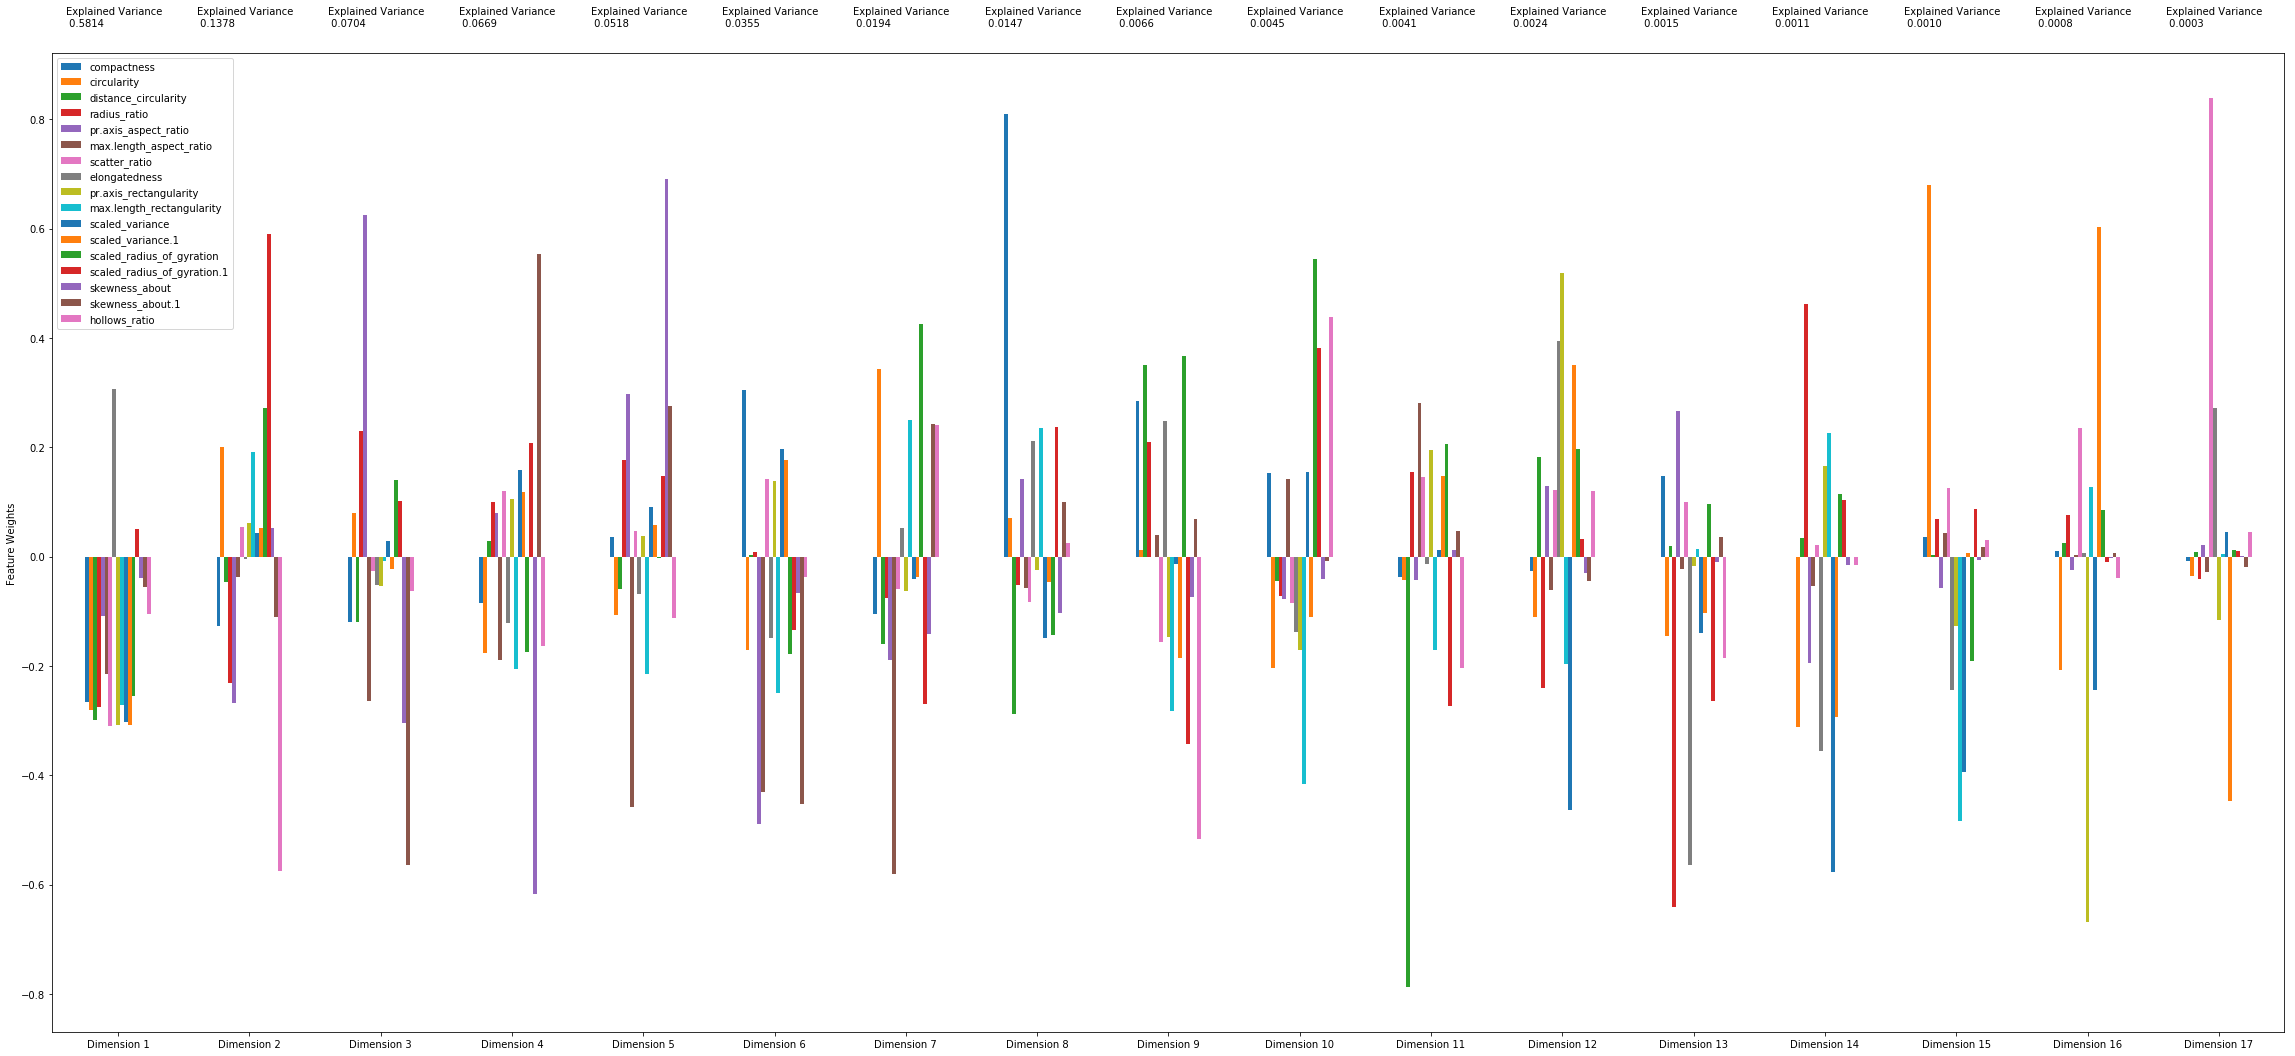

In [17]:
def pca_results(data, pca):
    
    # Dimension indexing
    dimensions = ['Dimension {}'.format(i) for i in range(1,len(pca.components_)+1)]
    
    # PCA components
    components = pd.DataFrame(np.round(pca.components_, 4), columns = data.keys()) 
    components.index = dimensions

    # PCA explained variance
    ratios = pca.explained_variance_ratio_.reshape(len(pca.components_), 1) 
    variance_ratios = pd.DataFrame(np.round(ratios, 4), columns = ['Explained Variance']) 
    variance_ratios.index = dimensions

    # Create a bar plot visualization
    fig, ax = plt.subplots(figsize = (40,18))

    # Plot the feature weights as a function of the components
    components.plot(ax = ax, kind = 'bar')
    ax.set_ylabel("Feature Weights") 
    ax.set_xticklabels(dimensions, rotation=0)

    # Display the explained variance ratios# 
    for i, ev in enumerate(pca.explained_variance_ratio_): 
        ax.text(i-0.40, ax.get_ylim()[1] + 0.05, "Explained Variance\n %.4f"%(ev))

    # Return a concatenated DataFrame
    return pd.concat([variance_ratios, components], axis = 1)

pca_results = pca_results(data, pca)

In [18]:
pca_results.cumsum()

,Explained Variance,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,hollows_ratio
Dimension 1,0.5814,-0.2662,-0.2810,-0.2994,-0.2745,-0.1080,-0.2147,-0.3100,0.3057,-0.3077,-0.2706,-0.3033,-0.3077,-0.2549,0.0508,-0.0394,-0.0551,-0.1055
Dimension 2,0.7192,-0.3937,-0.0804,-0.3451,-0.5063,-0.3766,-0.2529,-0.2564,0.3014,-0.2459,-0.0793,-0.2609,-0.2558,0.0162,0.6401,0.0136,-0.1653,-0.6804
Dimension 3,0.7896,-0.5134,-0.0004,-0.4655,-0.2760,0.2473,-0.5173,-0.2822,0.2492,-0.2999,-0.0872,-0.2330,-0.2777,0.1560,0.7410,-0.2914,-0.7293,-0.7442
Dimension 4,0.8565,-0.5992,-0.1771,-0.4373,-0.1761,0.3270,-0.7060,-0.1627,0.1285,-0.1951,-0.2924,-0.0744,-0.1602,-0.0190,0.9494,-0.9088,-0.1765,-0.9085
Dimension 5,0.9083,-0.5631,-0.2840,-0.4972,0.0013,0.6240,-1.1649,-0.1163,0.0599,-0.1582,-0.5065,0.0157,-0.1026,-0.0224,1.0959,-0.2175,0.0996,-1.0201
Dimension 6,0.9438,-0.2592,-0.4541,-0.4935,0.0099,0.1348,-1.5952,0.0249,-0.0898,-0.0193,-0.7557,0.2127,0.0738,-0.2008,0.9624,-0.2840,-0.3532,-1.0570
Dimension 7,0.9632,-0.3637,-0.1109,-0.6537,-0.0664,-0.0541,-2.1761,-0.0341,-0.0377,-0.0819,-0.5066,0.1721,0.0359,0.2248,0.6923,-0.4250,-0.1100,-0.8157
Dimension 8,0.9779,0.4465,-0.0396,-0.9418,-0.1183,0.0870,-2.2328,-0.1178,0.1743,-0.1059,-0.2713,0.0232,-0.0103,0.0820,0.9289,-0.5285,-0.0110,-0.7911
Dimension 9,0.9845,0.7318,-0.0273,-0.5917,0.0915,0.0859,-2.1942,-0.2744,0.4230,-0.2525,-0.5535,0.0091,-0.1951,0.4481,0.5859,-0.6026,0.0583,-1.3074
Dimension 10,0.9890,0.8854,-0.2311,-0.6359,0.0191,0.0076,-2.0529,-0.3589,0.2841,-0.4231,-0.9698,0.1643,-0.3065,0.9924,0.9680,-0.6430,0.0502,-0.8689


# Observation Dimension 7 covers around more than 96% of Variance

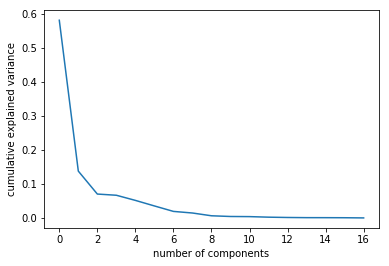

In [19]:
#Explained variance
plt.plot(pca.explained_variance_ratio_)
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.show()

# Observation:- From the above plot we can observe that we got that elbow in the plot corresponding to the 2nd number of principal components. Hence we should use only two number of principal components in our analysis.

In [20]:
vehicle_df.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,1
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,1
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,2
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,1
6,97,43.0,73.0,173.0,65.0,6,153.0,42.0,19.0,143,176.0,361.0,172.0,66.0,13.0,1.0,200.0,204,3


## 4. Use Support vector machines and use grid search (try C values - 0.01, 0.05, 0.5, 1 and kernel = linear, rbf) and find out the best hyper parameters and do cross validation to find the accuracy. (10 points)

In [21]:
# Train Test split 
target = vehicle_df["class"].astype('int64')
features = vehicle_df.drop(["class"], axis=1)
X_train1, X_test1, y_train1, y_test1 = train_test_split(features,target, test_size = 0.2, random_state = 10)


In [ ]:
#from sklearn import svm, grid_search
#def svc_param_selection(X, y, nfolds):
#    Cs = [0.01, 0.05, 0.5, 1]
#    gammas = [0.01, 0.05, 0.5, 1]
#    param_grid = {'C': Cs, 'gamma' : gammas}
#    grid_search = GridSearchCV(svm.SVC(kernel='rbf'), param_grid, cv=nfolds)
#    grid_search.fit(X, y)
#    grid_search.best_params_
#    return grid_search.best_params_

In [22]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV

In [23]:
 param_grid = [    {        
     'kernel': ['linear', 'rbf'],        
     'C': [ 0.01, 0.05, 0.5, 1]    } ]

In [24]:
from sklearn import svm
from sklearn.svm import SVC
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=4, n_jobs=multiprocessing.cpu_count())

In [25]:
gs.fit(X_train1, y_train1) 

GridSearchCV(cv=4, error_score='raise-deprecating',
       estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
  kernel='rbf', max_iter=-1, probability=False, random_state=None,
  shrinking=True, tol=0.001, verbose=False),
       fit_params=None, iid='warn', n_jobs=4,
       param_grid=[{'kernel': ['linear', 'rbf'], 'C': [0.01, 0.05, 0.5, 1]}],
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring='accuracy', verbose=0)

In [26]:
gs.best_estimator_

SVC(C=0.01, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
  kernel='linear', max_iter=-1, probability=False, random_state=None,
  shrinking=True, tol=0.001, verbose=False)

In [27]:
gs.best_score_ 

0.9453860640301318